In [1]:
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, tree_util
from functools import partial
from matplotlib import pyplot as plt
from scipy import constants as const
import diffrax as dif
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

G = const.G / (3.0857E+16)**3 * 1.989E+30 * (3.0857E+13)**2 #impurity ist ok (G ist konstant über die Auswertung)
                            #Umrechnung in pc^3/M_sun/s^2 (grav pot in (km/s)^2)
                            #Umrechnung, sodass z in parsec

#Formulierung des Anfangswertproblems (z taucht in den Formeln auf, um an anderen DGLs zu testen)
f = lambda rho_dm, params, z, u: jnp.array([u[1], \
            4*jnp.pi*G * (jnp.sum(params[:,0]*jnp.exp(-u[0]/params[:,1]**2)) + rho_dm)])
z0 = 0.
z1 = 1200.
u0 = jnp.array([0.,0.])
rho_dm = 0.025 #M_sun/pc^3
params = jnp.array([[0.021, 4.], [0.016, 7.], [0.012, 9.], \
                    [0.0009, 40.], [0.0006, 20.], [0.0031, 7.5], \
                    [0.0015, 10.5], [0.0020, 14.], [0.0022, 18.], \
                    [0.007, 18.5], [0.0135, 18.5], [0.006, 20.], \
                    [0.002, 20.], [0.0035, 37.], [0.0001, 100.]])

In [2]:
@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV2(rho_dm, params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(rho_dm, params, z0, dz, u0, f):
        k1 = dz * f(rho_dm, params, z0, u0)
        k2 = dz * f(rho_dm, params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(rho_dm, params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(rho_dm, params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1

    def rk4_step_scan(u, x):
        return rk4_step(rho_dm, params, x, dz, u, f), \
            rk4_step(rho_dm, params, x, dz, u, f)

    zs = jnp.linspace(z0, z1, n)
    _, uz = lax.scan(rk4_step_scan, u0, zs[:-1])
    uz = jnp.concatenate([jnp.array([u0]), uz], axis=0)

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5(rho_dm, params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args[0], args[1], z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(steps=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(rho_dm, params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5n(rho_dm, params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args[0], args[1], z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(ts=jnp.linspace(0, z1, n))
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(rho_dm, params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

# f_analytical = lambda z: -1e-2*z + jnp.cosh(0.1*z)

def block_until_ready(pytree):
  return tree_util.tree_map(lambda x: x.block_until_ready(), pytree)

In [3]:
ns = [5, 10, 20, 50, 100, 200, 500, 750, 1000, 1500, 2000]

df_e = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

for n in ns:
    uz_eigen, zs_eigen = eigenerSolverV2(rho_dm, params, z0, z1, u0, f, n)
    t = %timeit -o block_until_ready(eigenerSolverV2(rho_dm, params, z0, z1, u0, f, n))

    # abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
    # abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
    # abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

    df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen]

df_e.to_string('benchmark_eigen_real.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

9.75 µs ± 101 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_46352\1440662547.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen]


10.4 µs ± 43.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
11.5 µs ± 148 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
14.8 µs ± 150 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
20.8 µs ± 334 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
32 µs ± 1.39 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
63.5 µs ± 222 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
91.2 µs ± 489 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
121 µs ± 479 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
180 µs ± 596 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
241 µs ± 7.18 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


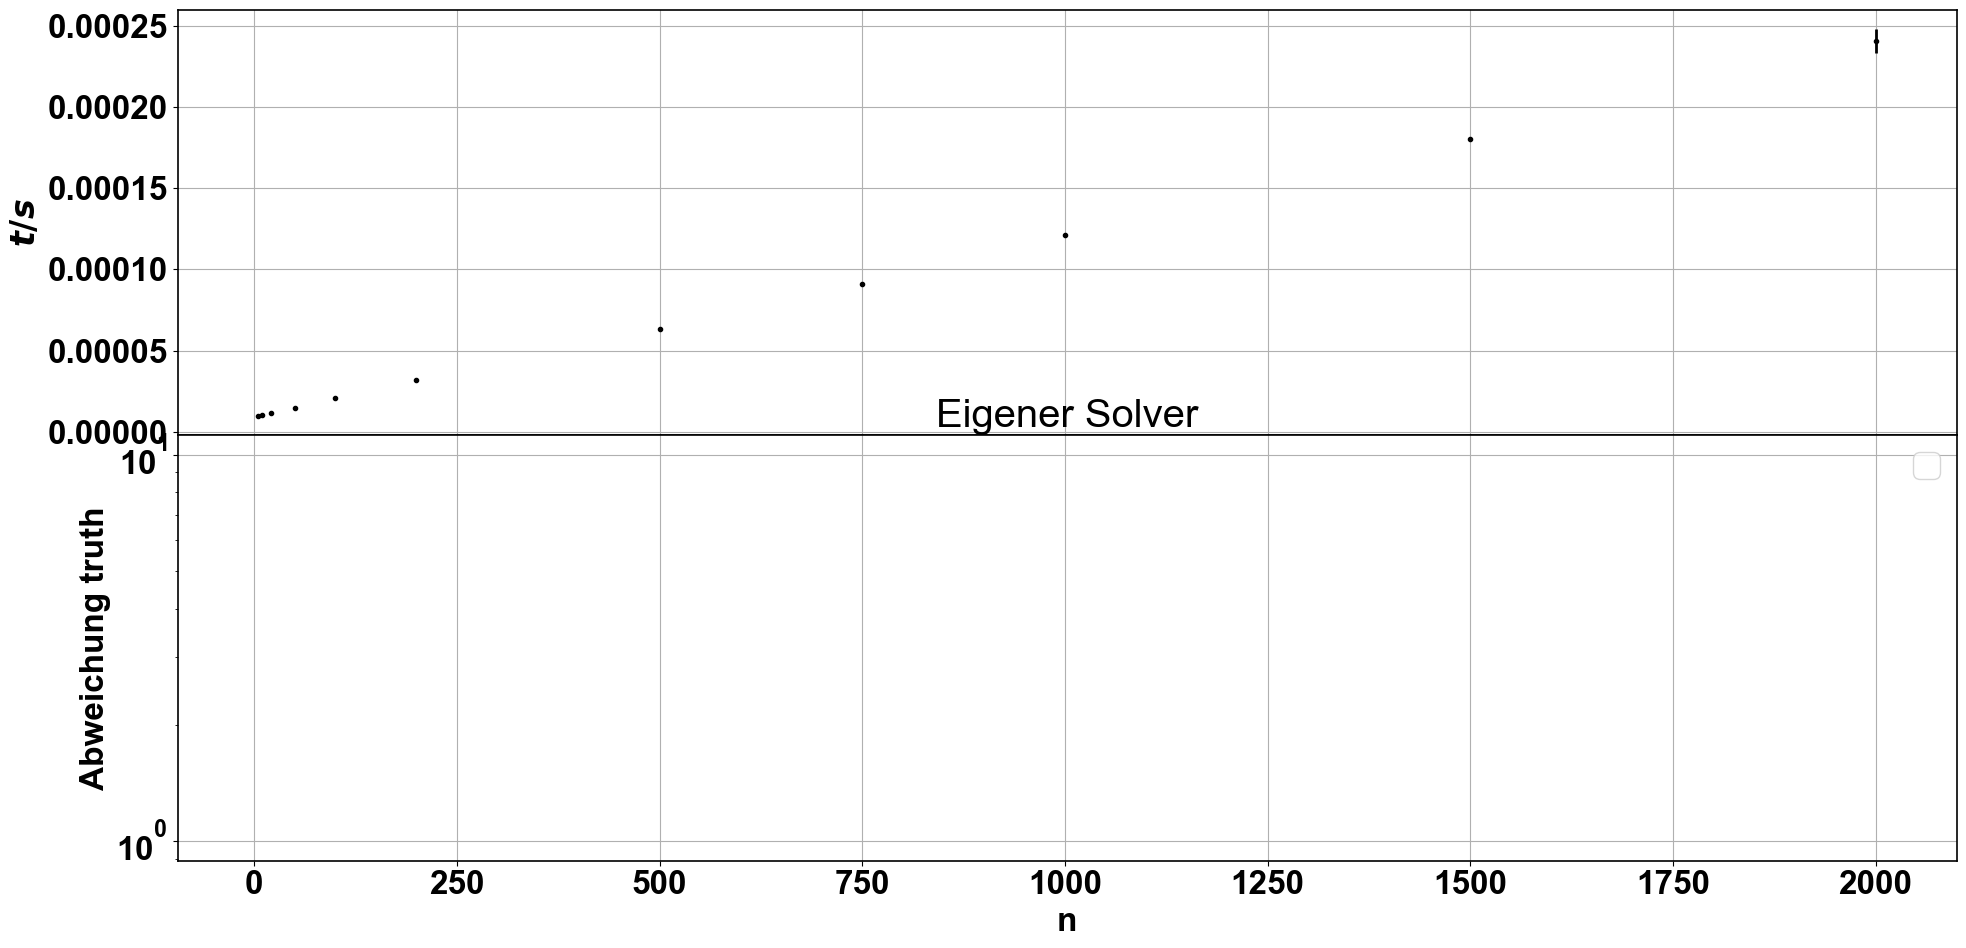

In [4]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Eigener Solver')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_e['n'], df_e['t_mean'], yerr=df_e['t_std'], color='black', fmt = '.')
ax[0].grid()
#ax[1].set_xscale('log')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
# ax[1].scatter(df_e['n'], df_e['abw_mean_eigen'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_e['n'], df_e['abw_max_eigen'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [5]:
rtol = 0
atols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8] #für 1e-9 läuft er in das max_step limit (default = 4096)

df_d = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for atol in atols:
    uz_dopri, zs_dopri = diffraxDopri5(rho_dm, params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5(rho_dm, params, z0, z1, u0, f, n, rtol, atol))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    # abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    # abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    # abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_d = pd.concat([df_d, pd.DataFrame({'atol':[atol], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri]



df_d.to_string('benchmark_dopri_real.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)


188 µs ± 851 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_46352\911711554.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_d = pd.concat([df_d, pd.DataFrame({'atol':[atol], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri]


189 µs ± 670 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
191 µs ± 1.23 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
191 µs ± 2.1 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
195 µs ± 1.32 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
198 µs ± 644 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
217 µs ± 1.76 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
486 µs ± 7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


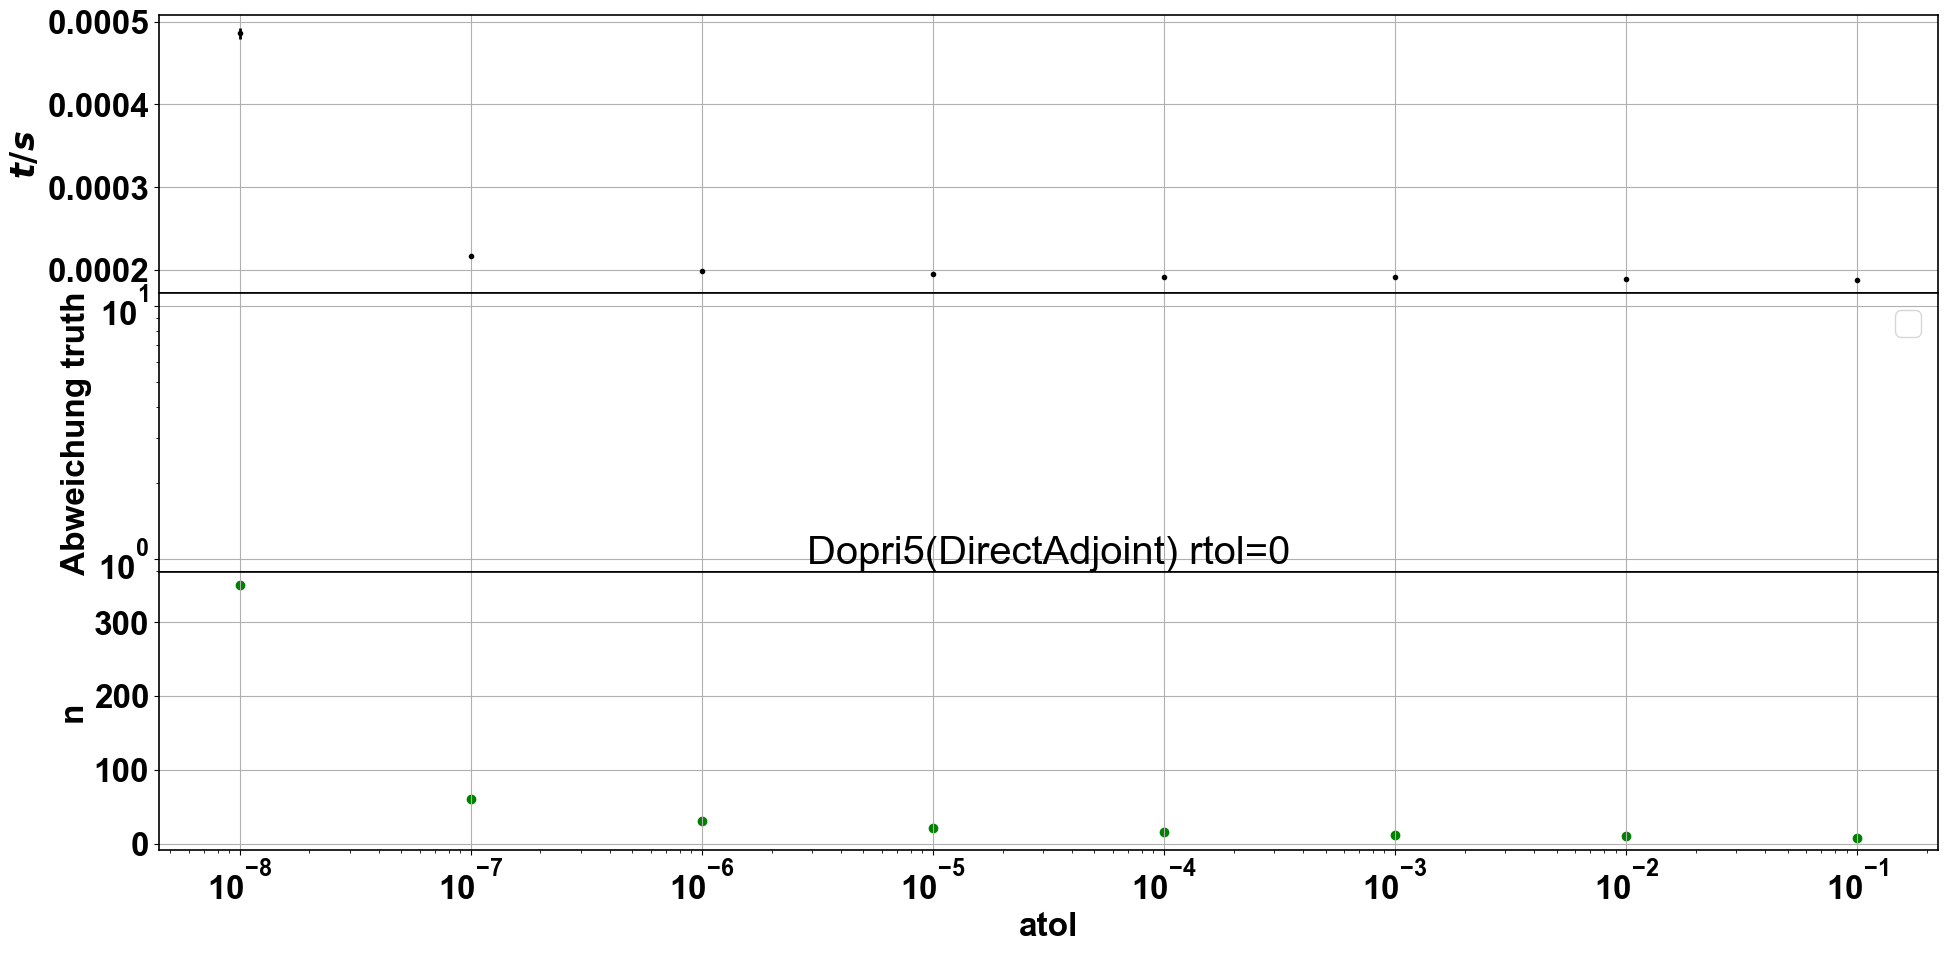

In [6]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_d['atol'], df_d['t_mean'], yerr=df_d['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
# ax[1].scatter(df_d['atol'], df_d['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_d['atol'], df_d['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('atol')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_d['atol'], df_d['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [7]:
ns = [5, 10, 50, 100, 500, 1000, 2000]
rtol = 0
atol = 1e-6

df_dn = pd.DataFrame(columns=['abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for n in ns:
    uz_dopri, zs_dopri = diffraxDopri5n(rho_dm, params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5n(rho_dm, params, z0, z1, u0, f, n, rtol, atol))

    # abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    # abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    # abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_dn = pd.concat([df_dn, pd.DataFrame({'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri]



df_dn.to_string('benchmark_doprin_real.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

179 µs ± 1.75 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_46352\704973001.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dn = pd.concat([df_dn, pd.DataFrame({'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True) #'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri]


181 µs ± 1.52 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
180 µs ± 922 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
180 µs ± 1.38 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
184 µs ± 2.46 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
188 µs ± 922 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
198 µs ± 1.15 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


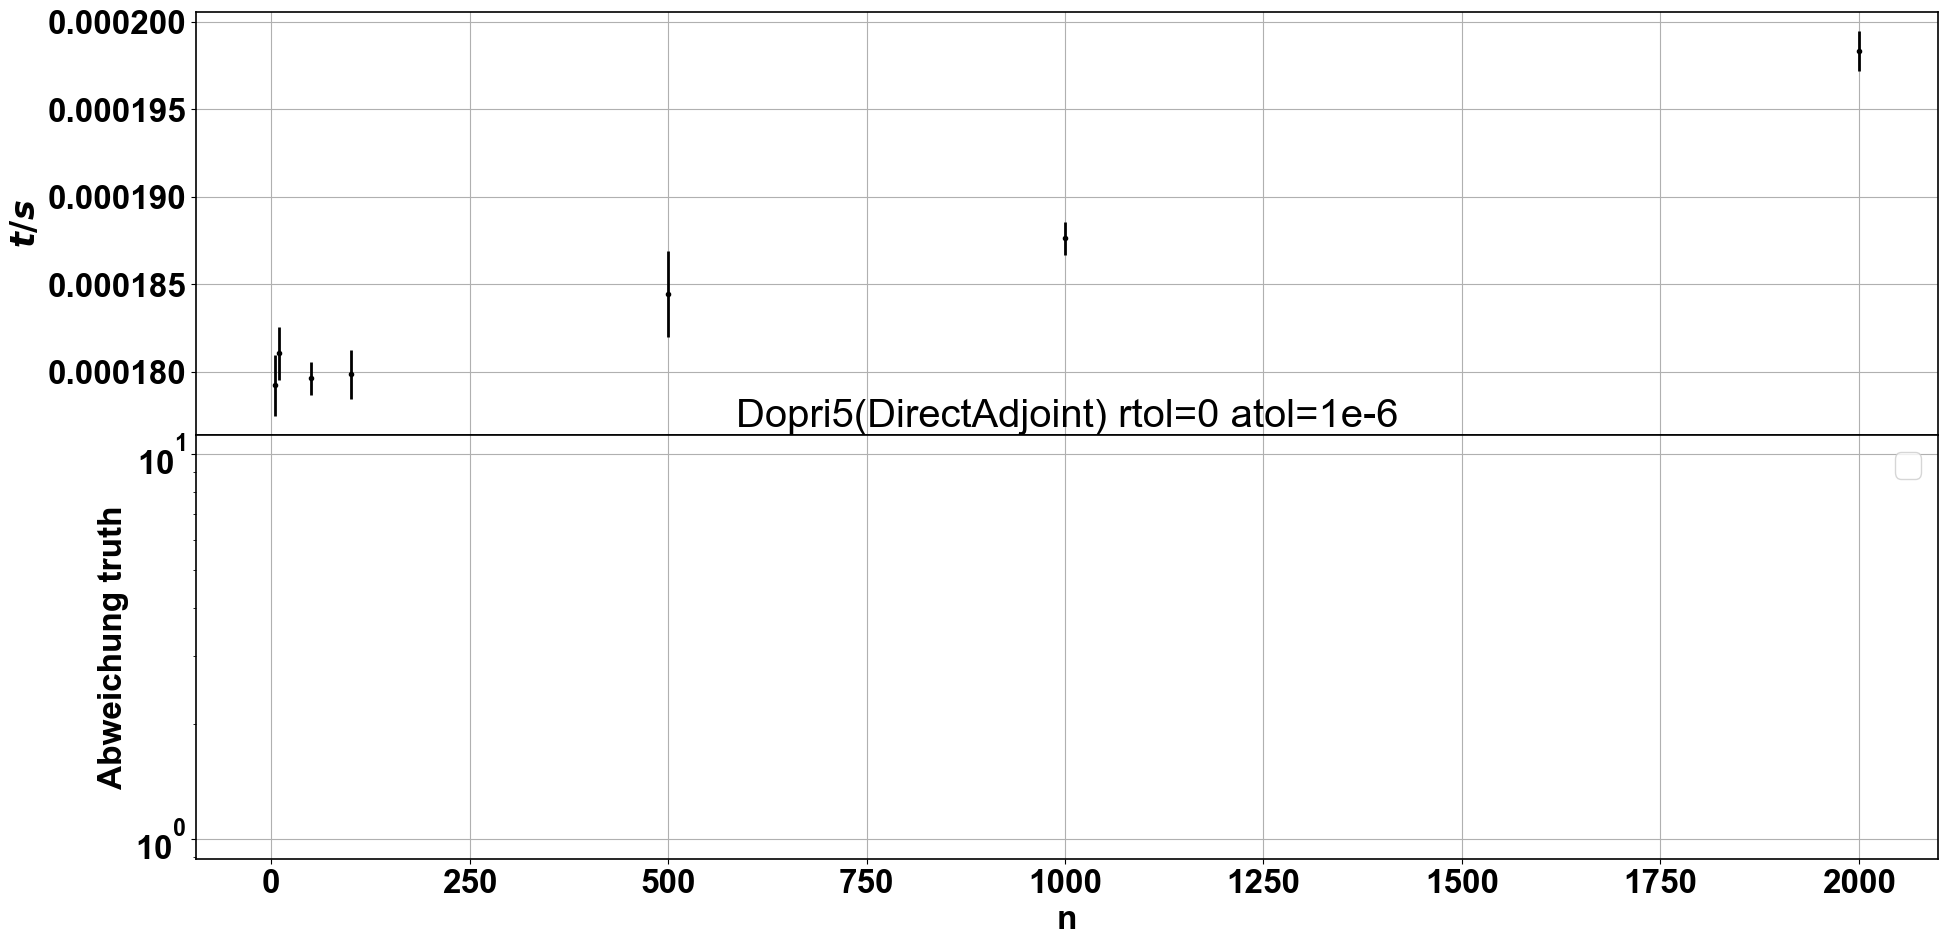

In [8]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0 atol=1e-6')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_dn['n'], df_dn['t_mean'], yerr=df_dn['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
# ax[1].scatter(df_dn['n'], df_dn['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
# ax[1].scatter(df_dn['n'], df_dn['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel('n')
#ax[1].set_xscale('log')
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)